<a href="https://colab.research.google.com/github/davidmkidd/UK-Supermarket-Carbon-Emissions/blob/main/UKSmktComp_Emissions_Scope2_Location.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://evoviz.uk/wp-content/uploads/2026/04/Food_Divider_trans2.png">

# Scope 2 Location-based

Scope 2 are the emissions that arise from purchased energy that for UK supermarkets is mostly electricity from the UK National Grid so,

> $C_{s2, loc} \approx C_{electricity}$

and

> $C_{electricity} = E_{electricity} * I_{Grid}$

# Set-up



In [ ]:
# Load libraries
library(dplyr)   # Data manipulation
library(ggplot2) # Graphing
library(repr)    # Graph size
options(repr.plot.width = 10, repr.plot.height = 8)
library(broom)   # Format model output
library(knitr)    # Format model output

# Download summarised emmissions data
url <- "https://raw.githubusercontent.com/davidmkidd/UK-Supermarket-Carbon-Emissions/refs/heads/main/retailer_emissions_yr.csv"
download_path <- "/content/retailer_emissions_yr.csv"
download.file(url, destfile = download_path, mode = "wb")
emissions.yr <- read.csv("/content/retailer_emissions_yr.csv", header=TRUE, stringsAsFactors=FALSE)

# Download retailer data
url <- "https://raw.githubusercontent.com/davidmkidd/UK-Supermarket-Carbon-Emissions/refs/heads/main/retailer_data.csv"
download_path <- "/content/retailer_data.csv"
download.file(url, destfile = download_path, mode = "wb")
retailer.data <- read.csv("/content/retailer_data.csv", header=TRUE, stringsAsFactors=FALSE)

# Make palette list
retailer.pal <- setNames(retailer.data$hex, retailer.data$retailer_code)
# Make code/name list
retailer.code <- setNames(retailer.data$retailer, retailer.data$retailer_code)

# Truncate year to 1s and 10s for display
emissions.yr$year2 <- emissions.yr$year - 2000

# Split reported absolute and intenstity values into seperate data frames as they will will be used differenty.

# Reported Absolute Values
emissions.yr.absolute <- emissions.yr %>%
   filter(kpi_type == "Measure")

# Reported Intensity Values
emissions.yr.intensity <- emissions.yr %>%
   filter(kpi_type == "Intensity")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




# Reported Emissions

In [ ]:
# Get Reported Absolute Scope 2 location-based emissions and order
data.abs <-  emissions.yr.absolute %>%
  filter(kpi == "Scope 2" & kpi_type == "Measure" & method == "Location") %>%
  arrange(retailer_code, year)
nrow(data.abs)

[1] 98

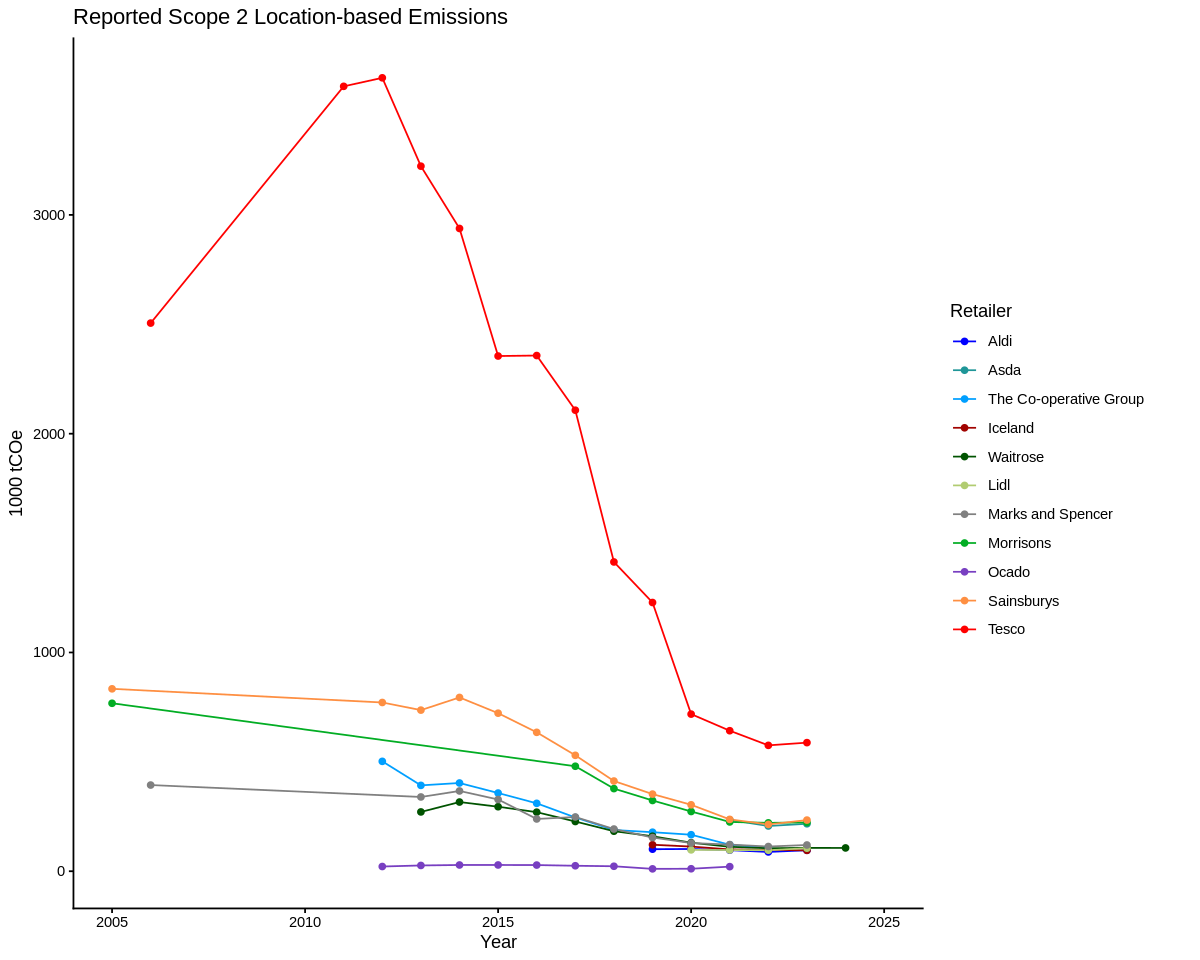

In [ ]:
# Plot Absolute Scope 2 location-based emissions
ggplot(data.abs, aes(x = year, y = value/1000, colour = retailer_code)) +
  geom_line(na.rm = TRUE)  +
  geom_point(na.rm = TRUE) +
  ggtitle("Reported Scope 2 Location-based Emissions") +
  xlab("Year") +
  ylab("1000 tCOe") +
  scale_x_continuous(limits = c(2005, 2025)) +
  scale_colour_manual(name = "Retailer", values = retailer.pal, labels = retailer.code) +
  theme_classic()

* Scope 2 location-based emissions of all retailers show long term reduction, except Ocado.
* Reductions have slowed or even started to rise suggesting efficiency savings may be limited.
* Tesco is the largest Scope 2 emittor with emissions peaking in 2010, then rapidly declined before bottoming-out around 2020.
* Sainsburys and Morrisons cluster with higher emissions that other retailers.
* Ocardo's carbon footprint is the lowest perhaps because it does purchase power for a network of stores.

## Retailer Size

Scope 2 emissions are expected to increase with retailer size.

In [ ]:
# Calculate mean emissions for years 2020 - 2022
data.abs.mean <- data.abs %>%
  filter(year >= 2020 & year <= 2022) %>%
  group_by(retailer_code) %>%
  summarise_at(vars(value, total_store, total_area),list(mean = mean))

### Store Number

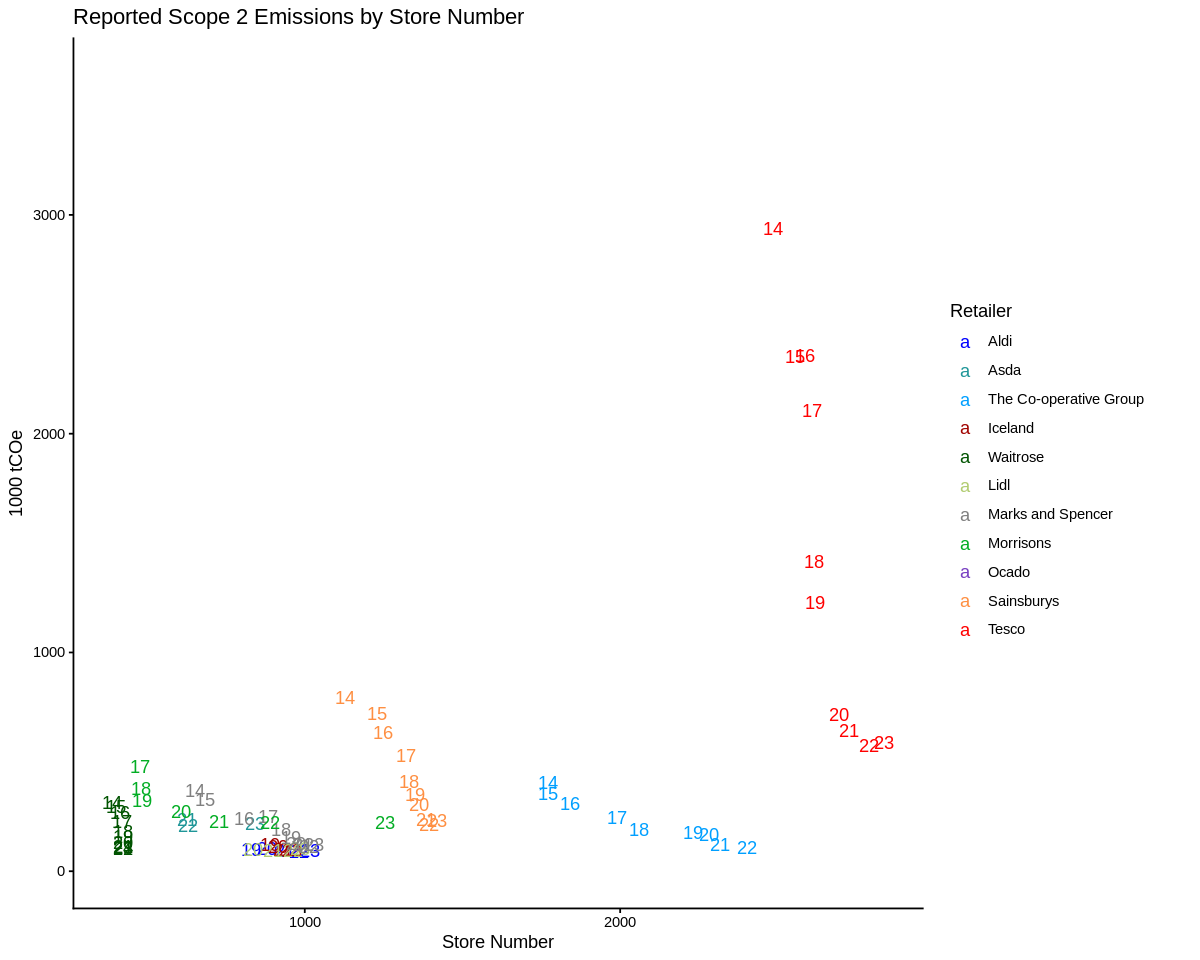

In [ ]:
# Plot Reported Values Against Store Number
ggplot(data.abs, aes(x = total_store, y = value/1000, colour = retailer_code, label = year2)) +
  geom_text(na.rm = TRUE) +
  ggtitle("Reported Scope 2 Emissions by Store Number") +
  xlab("Store Number") +
  ylab("1000 tCOe") +
  scale_colour_manual(name = "Retailer", values = retailer.pal, labels = retailer.code) +
  theme_classic()




| r.squared| adj.r.squared|  sigma| statistic| p.value| df|   logLik|     AIC|     BIC|     deviance| df.residual| nobs|
|---------:|-------------:|------:|---------:|-------:|--:|--------:|-------:|-------:|------------:|-----------:|----:|
|     0.441|         0.371| 132611|     6.316|   0.036|  1| -131.025| 268.051| 268.959| 140685315931|           8|   10|



|term             |  estimate| std.error| statistic| p.value|
|:----------------|---------:|---------:|---------:|-------:|
|(Intercept)      | 25018.331| 82039.188|     0.305|   0.768|
|total_store_mean |   147.667|    58.756|     2.513|   0.036|

`geom_smooth()` using formula = 'y ~ x'


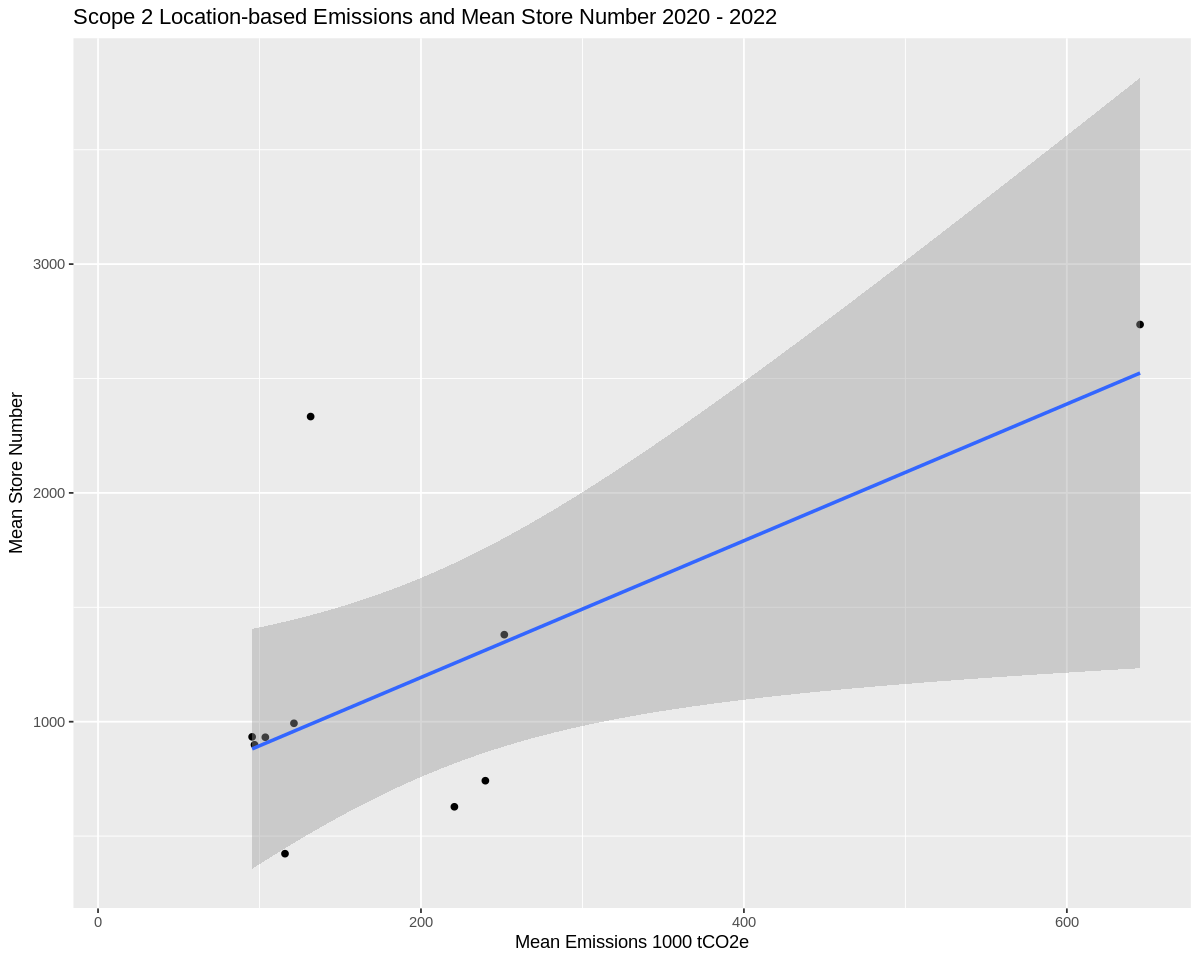

In [ ]:
# Scope 2 location ~ Store Number
lm_model <- lm(data = data.abs.mean, value_mean ~ total_store_mean, na.action=na.omit)
glance(lm_model) %>%
  kable(digits = 3)
tidy(lm_model) %>%
  kable(digits = 3)

ggplot(data.abs.mean, aes(x = value_mean/1000, y = total_store_mean)) +
  geom_point(na.rm = TRUE) +
  geom_smooth(method='lm', na.rm = TRUE) +
  ggtitle("Scope 2 Location-based Emissions and Mean Store Number 2020 - 2022") +
  xlab("Mean Emissions 1000 tCO2e") +
  ylab("Mean Store Number")

### Store Area

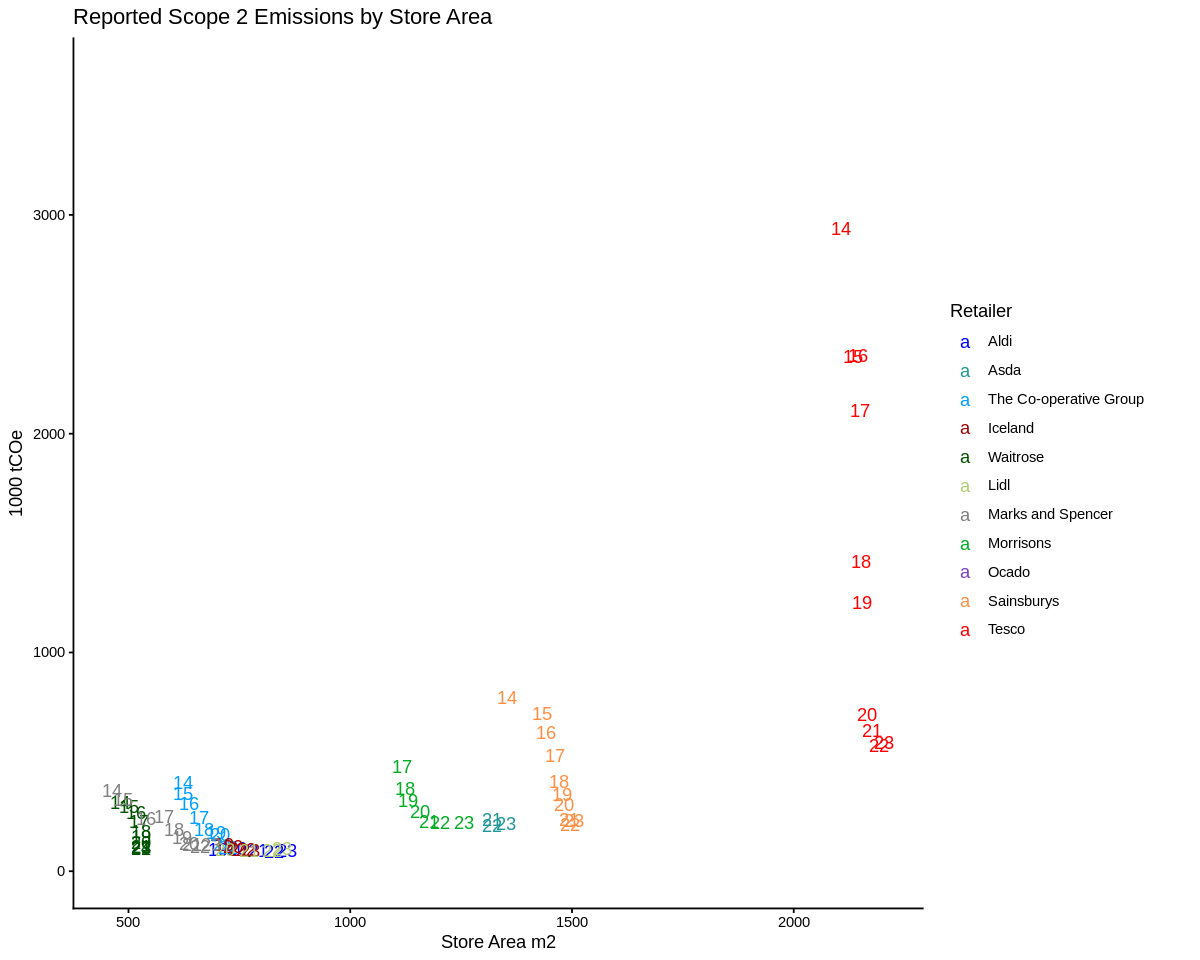

In [ ]:

# Plot Reported Values Against Store Area
ggplot(data.abs, aes(x = total_area/1000, y = value/1000, colour = retailer_code, label = year2)) +
  geom_text(na.rm = TRUE) +
  ggtitle("Reported Scope 2 Emissions by Store Area") +
  xlab("Store Area m2") +
  ylab("1000 tCOe") +
  scale_colour_manual(name = "Retailer", values = retailer.pal, labels = retailer.code) +
  theme_classic()



| r.squared| adj.r.squared|    sigma| statistic| p.value| df|   logLik|     AIC|     BIC|    deviance| df.residual| nobs|
|---------:|-------------:|--------:|---------:|-------:|--:|--------:|-------:|-------:|-----------:|-----------:|----:|
|      0.88|         0.865| 61505.29|    58.552|       0|  1| -123.342| 252.685| 253.593| 30263204222|           8|   10|



|term            |    estimate| std.error| statistic| p.value|
|:---------------|-----------:|---------:|---------:|-------:|
|(Intercept)     | -116658.843|  45989.29|    -2.537|   0.035|
|total_area_mean |       0.308|      0.04|     7.652|   0.000|

`geom_smooth()` using formula = 'y ~ x'


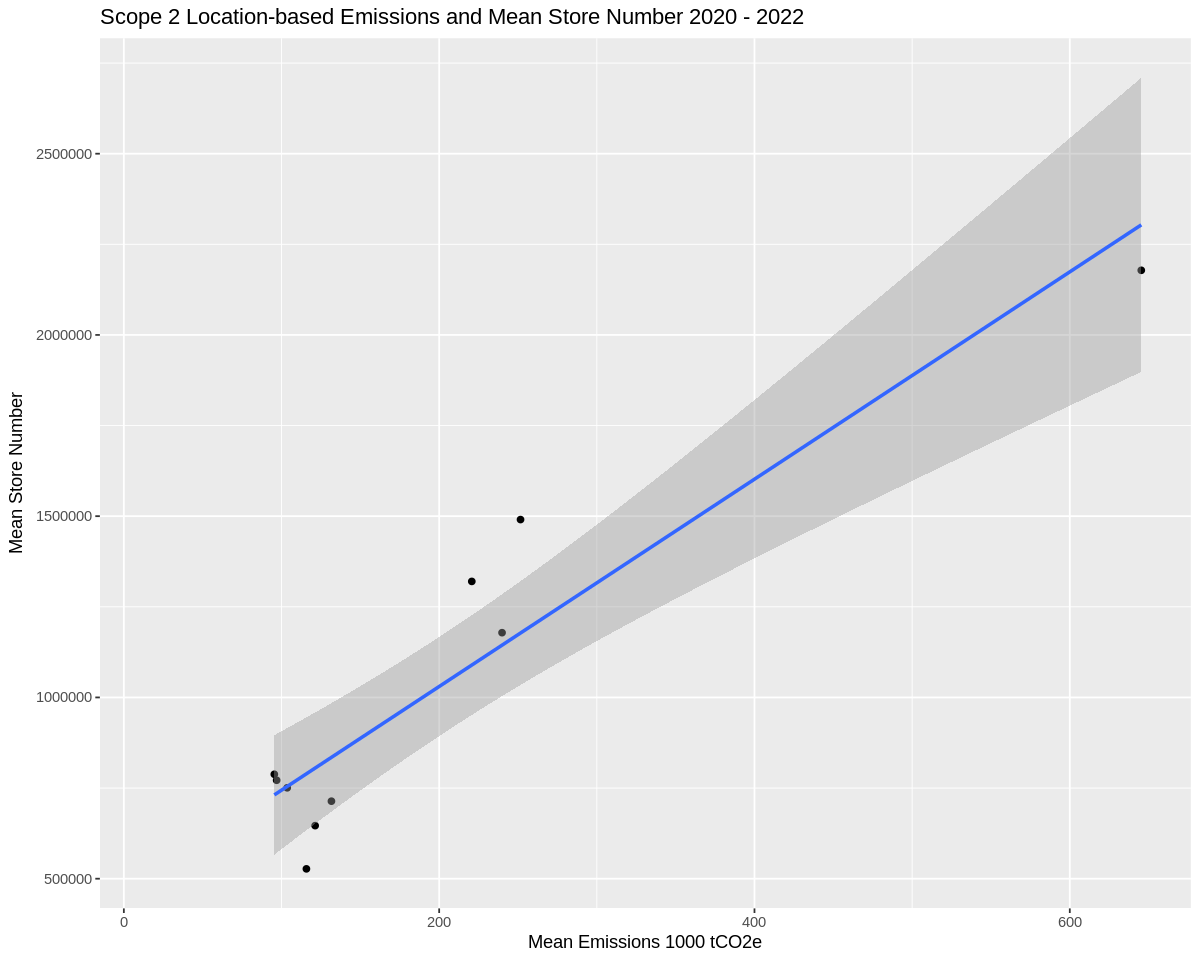

In [ ]:
# Scope 2 location ~ Store Area
lm_model <- lm(data = data.abs.mean, value_mean ~ total_area_mean, na.action=na.omit)
glance(lm_model) %>%
  kable(digits = 3)
tidy(lm_model) %>%
  kable(digits = 3)

ggplot(data.abs.mean, aes(x = value_mean/1000, y = total_area_mean)) +
  geom_point(na.rm = TRUE) +
  geom_smooth(method='lm', na.rm = TRUE) +
  ggtitle("Scope 2 Location-based Emissions and Mean Store Number 2020 - 2022") +
  xlab("Mean Emissions 1000 tCO2e") +
  ylab("Mean Store Number")

### Store Number and Area

In [ ]:
# Scope 2 location ~ Store Number + Store Area
lm_model <- lm(data = data.abs.mean, value_mean ~ total_store_mean + total_area_mean, na.action=na.omit)
paste("Store Number and Area")
glance(lm_model) %>%
  kable(digits = 3)
tidy(lm_model) %>%
  kable(digits = 3)
paste("")

[1] "Store Number and Area"



| r.squared| adj.r.squared|    sigma| statistic| p.value| df|   logLik|     AIC|     BIC|    deviance| df.residual| nobs|
|---------:|-------------:|--------:|---------:|-------:|--:|--------:|-------:|-------:|-----------:|-----------:|----:|
|     0.907|         0.881| 57792.21|    34.189|       0|  2| -122.052| 252.104| 253.315| 23379579643|           7|   10|



|term             |    estimate| std.error| statistic| p.value|
|:----------------|-----------:|---------:|---------:|-------:|
|(Intercept)      | -131776.515| 44477.474|    -2.963|   0.021|
|total_store_mean |      44.457|    30.967|     1.436|   0.194|
|total_area_mean  |       0.271|     0.046|     5.926|   0.001|

[1] ""

### Best Model

* Store number predicts 44% (r.squared) of Scope 2 emissions with *p* = 0.036.

* Store area predicts 88% of Scope emissions with *p* = <0.001.

* Both variables explain the most variation (90.7%), but store number is not significant (p = 0.194).

The best model is:  $Cscope2 \sim StoreArea$


In [ ]:
# Calculate estimated intensity for absolute values
data.abs$intensity <- data.abs$value/data.abs$total_area

## Emission Intensity

In [ ]:
# Are there any reported Scope 2 location-based intensity metrics
data.int <- emissions.yr.intensity %>%
  filter(kpi == "Scope 2" & method == "Location", unit_denom_1 == "m2")
nrow(data.int)

[1] 0

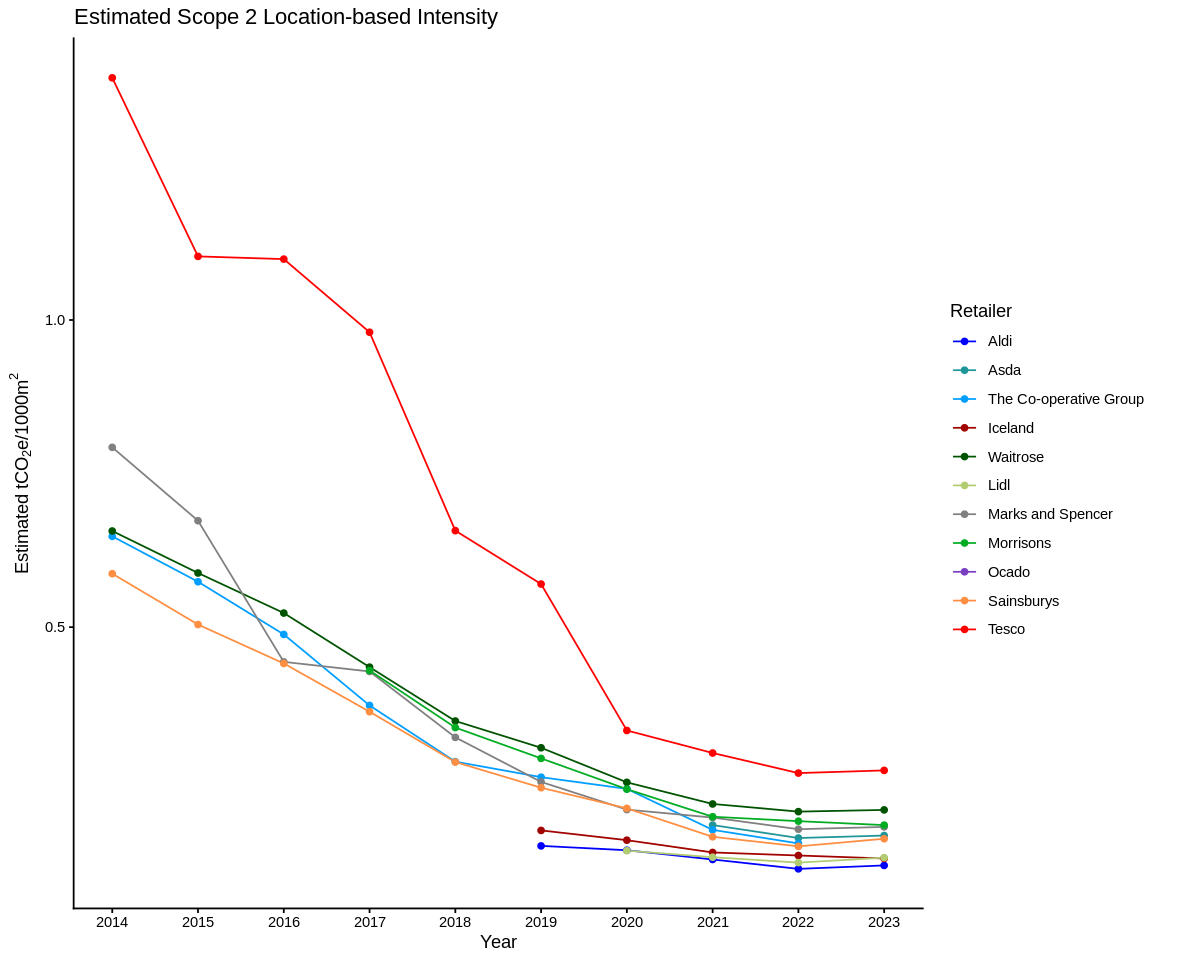

In [ ]:
# Estimated Scope 2 Intensity
ggplot(data.abs, aes(x = year, y = intensity, colour = retailer_code)) +
  geom_line(na.rm = TRUE)  +
  geom_point(na.rm = TRUE) +
  ggtitle("Estimated Scope 2 Location-based Intensity") +
  xlab("Year") +
  ylab(expression(paste("Estimated tCO"[2],"e/1000m"^2))) +
  scale_colour_manual(name = "Retailer", values = retailer.pal, labels = retailer.code) +
  scale_x_continuous(limits = c(2014, 2023), breaks=seq(2014,2023)) +
  theme_classic()

* Tesco is again the least efficient retailer, but has improved immensely.

* Low cost Aldi, Iceland, and Lidl have the lowest location based intensity footprints.

* Other retailers have followed very similar intensity reduction paths.

* Carbon intensity of the UK National Grid has also decreased over the same period as shown by the Annual UK Electricity Grid Carbon Intensity calculated from the NESO Historic generation mix and carbon intensity https://www.neso.energy/data-portal/historic-generation-mix [downloaded 01/04/26]. Electrical Energy is calculated from absolute location-based Scope 2 emissions and UK Grid Intensity in [Workbook 13](https://colab.research.google.com/drive/1Wv1RPVjFY6nKbBP7ZAE_RSzXb1Tu8jhz?usp=sharing).



### UK Grid Intensity

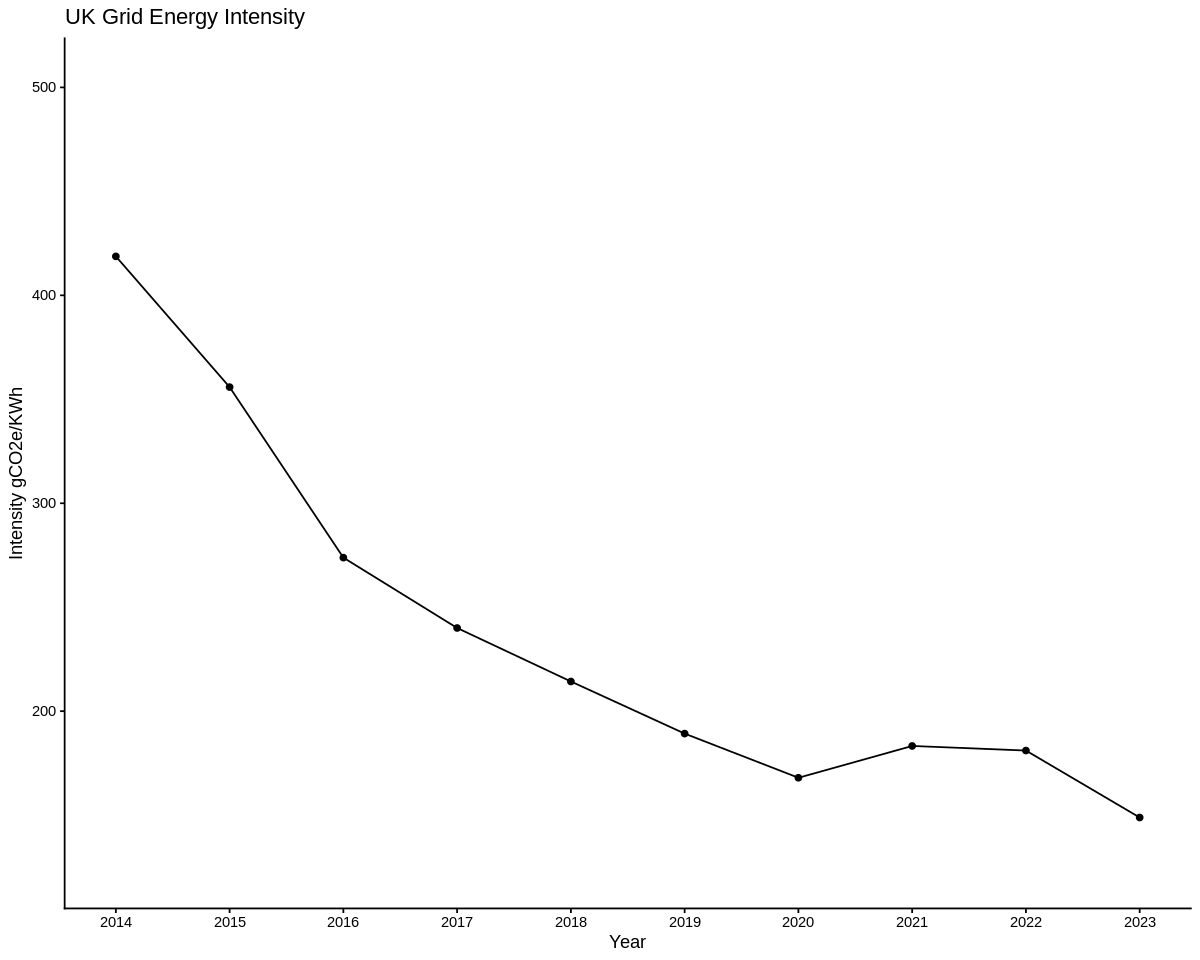

In [ ]:
# Load UK Grid Intensity
url <- "https://raw.githubusercontent.com/davidmkidd/UK-Supermarket-Carbon-Emissions/refs/heads/main/mean_uk_grid_intensity.csv"
download_path <- "/content/mean_uk_grid_intensity.csv"
download.file(url, destfile = download_path, mode = "wb")
#Import
grid.intensity <- read.csv("/content/mean_uk_grid_intensity.csv", header=TRUE, stringsAsFactors=FALSE)

# Mean Carbon Intensity of UK Grid
ggplot(grid.intensity, aes(x = year, y = intensity)) +
  geom_line(na.rm = TRUE)  +
  geom_point(na.rm = TRUE) +
  ggtitle("UK Grid Energy Intensity") +
  xlab("Year") +
  ylab("Intensity gCO2e/KWh") +
  scale_x_continuous(limits = c(2014, 2023), breaks=seq(2014,2023)) +
  theme_classic()


---
[Main Page](https://colab.research.google.com/drive/1f8a0pXfF9PqCujiwjf4TO4-k7ezt-6b3?usp=sharing)

[Scope 2 Market](https://colab.research.google.com/drive/1_NcLYci-JUDkaC-Rsi6FOJ8CA38BahGW?usp=sharing)

---